<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b>

<b>Проект: Анализ лояльности пользователей Яндекс Афиши</b>
<p><b>Цель проекта -</b> Исследовательский анализ пользователей Яндекс Афиши</p>

<p><b>Задачи проекта:</b></p>
<ul>
    <li>Выявление перспективных клиентов, которым можно предлагать персонализированные условия.</li>
    <li>Исследовательский анализ данных для настройки рекламы на аудиторию с высокой вероятностью возврата.</li>
    <li>Исследовательский анализ данных для оптимизации маркетенговых бюджетов.</li>
    <li>Исследовательский анализ данных для повышения общего уровня удержания клиентов.</li>
</ul>

<p><b>Выгрузка с базы данных производиться в отдельном файле "load_database.py" и сохраняется в файл "afisha.csv"</b></p>

<p><b>Описание данных afisha.csv -</b> Датафрейм содержит 15 столбцов, 290611 строк.</p>
<p>Столбцы</p>
<ul>
    <li><b>user_id</b> - Уникальный идентификатор пользователя, совершившего заказ.</li>
    <li><b>device_type_canonical</b> - Тип устройства, с которого был оформлен заказ (mobile - мобильный, desktop - стационарные).</li>
    <li><b>order_id</b> - Уникальный идентификатор заказа.</li>
    <li><b>order_dt</b> - Дата создания заказа.</li>
    <li><b>order_ts</b> - Дата и время создания заказа.</li>
    <li><b>currency_code</b> - Валюта оплаты.</li>
    <li><b>revenue</b> - Выручка от заказа.</li>
    <li><b>tickets_count</b> - Количество купленных билетов.</li>
    <li><b>days_since_prev</b> - Количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой - значение пропущено.</li>
    <li><b>event_id</b> - Уникальный идентификатор мероприятия.</li>
    <li><b>service_name</b> - Название билетного оператора.</li>
    <li><b>event_type_main</b> - Основной тип мероприятия (театральная постановка, концерт и так далее).</li>
    <li><b>region_name</b> - Название региона, в котором прошло мероприятие.</li>
    <li><b>city_name</b> - Названи города, в котором прошло мероприятие.</li>
</ul>
<p><b>Описание данных final_tickets_tenge_df.csv -</b> Датафрейм содержит 4 столбца, 357 строк.</p>
<p>Столбцы</p>
<ul>
    <li><b>data</b> - Дата, в которую данный курс был актуален.</li>
    <li><b>nominal</b> - Номинальное представление в теньге.</li>
    <li><b>curs</b> - Курс в рублях для представленного номинала.</li>
    <li><b>cdx</b> - Валюта из которой будет производиться конвертирование.</li>
</ul>

<p><b>Содержание проекта:</b></p>
<ol>
    <li>Загрузка всех необходимых библиотек.</li>
    <li>Загрузка данных и их предобработка.
        <ol>
            <li>Загрузка основных данных из базы data-analyst-afisha и знакомство с данными.</li>
            <li>Загрузка датафрейма final_tickets_tenge_df.csv для конвертирования валют и знакомство с ним.</li>
        </ol>
    </li>
    <li>Предобработка данных.
        <ol>
            <li>Преведение выручки к единой валюте - российскому рублю.</li>
            <li>Преобразование типов данных и коррекция столбцов.</li>
            <li>Проверка распределения численных данных.</li> 
        </ol>
    </li>
    <li>Создание профиля пользователя
        <ol>
            <li>Построение профиля пользователя.</li> 
            <li>Рассчёт статистических показателей для оценки данных.</li> 
        </ol>
    </li>
    <li>Исследовательский анализ данных
        <ol>
            <li>Исследование признаков первого заказа и их связи с возвращением на платформу.
                <ol>
                    <li>Изучение распределения пользователей по признакам.</li>
                    <li>Анализ возврата пользователей</li>
                </ol>
            </li>
            <li>Исследование поведения пользователей через показатели выручки и состава заказа
                <ol>
                    <li>Анализ связи между средней выручкой сервиса с заказа и повторными заказами</li>
                    <li>Сравнение распределения по средней выручке с заказа в группах (2-4 заказа, 5 и более заказов)</li>
                    <li>Анализ влияния среднего количества билетов в заказе на вероятность повторной покупки.</li>
                </ol>
            </li>
            <li>Исследование временных характеристик первого заказа и их влияния на повторные покупки.
                <ol>
                    <li>Анализ влияния дня недели первой покупки на поведение пользователей.</li>
                    <li>Анализ того, ка ксредний интервал между заказами влияет на удержание клиентов</li>
                </ol>
            </li>
            <li>Корреляционный анализ количества покупок и признаков пользователя</li>
        </ol>
    </li>
    <li>Общие выводы на основе исследований.</li>
</ol>

In [1]:
# Установка необходимых библиотек
# !pip install sqlalchemy 
# !pip install psycopg2 
!pip install phik -U 

In [2]:
# Импортирование необходимых библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot
import phik
from dotenv import load_dotenv
from sqlalchemy import create_engine 
import os

In [3]:
# 1 Загрузка данных и их предобработка.
## 1.1 Загрузка основных данных из базы data-analyst-afisha и знакомство с данными.
# df = pd.read_csv('./data/afisha.csv')

load_dotenv()
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv('db_user'),
    os.getenv('db_password'),
    os.getenv('db_host'),
    os.getenv('db_port'),
    os.getenv('db_name')
)

engine = create_engine(connection_string) 

query = '''
    SELECT
        -- Информация о пользователе:
        user_id,
        device_type_canonical,
        -- Информация о заказе:     
        order_id, -- Номер заказа
        created_dt_msk AS order_dt, -- Дата заказа
        created_ts_msk AS order_ts, -- Время заказа
        currency_code, -- Код валюты
        revenue, -- Выручка сервиса
        tickets_count, -- Кол-во билетов
        -- Время между заказами для каждого пользователя:
        created_dt_msk::date - LAG(created_dt_msk::date ) 
            OVER(PARTITION BY user_id ORDER BY created_dt_msk)
            AS days_since_prev,
        -- Информация о мероприятии:  
            p.event_id,
            service_name,
            e.event_name_code AS event_name,
            e.event_type_main,
            -- Выгрузка информации о городе и регионе:
            r.region_name,
            c.city_name
        FROM afisha.purchases AS p
        INNER JOIN afisha.events AS e USING (event_id)
        LEFT JOIN afisha.city AS c USING(city_id)
        LEFT JOIN afisha.regions AS r USING(region_id)
    WHERE
        -- Фильтрация по типу устройства
        device_type_canonical IN ('mobile','desktop') 
        -- Убираем данные о фильмах
        AND
        e.event_type_main != 'фильм'
    ORDER BY user_id;
''' 

df = pd.read_sql_query(query, con=engine) 

df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])
display(df.sample(5))
display(df.info())

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_name,event_type_main,region_name,city_name
127581,61b8f9a97792599,mobile,838362,2024-10-08,2024-10-08 21:55:17,rub,1120.57,3,0.0,454398,Билеты в руки,7718535d-92c0-45a1-9c4c-6cd78197fbcc,концерты,Широковская область,Луговаярово
278876,f6af1139a64d911,mobile,3190523,2024-09-17,2024-09-17 23:02:09,rub,108.07,5,0.0,542619,Билеты без проблем,b92cc6f5-b351-4c1b-8a50-c232121dca14,другое,Речицкая область,Радужанов
187048,99e2d4517d86b2b,mobile,2673946,2024-07-14,2024-07-14 06:39:01,rub,58.71,2,0.0,247905,Лови билет!,c6e7d1ba-7c34-44cb-b6cf-4c472523b2ea,театр,Светополянский округ,Глиноград
84609,3ee7dc2e115847f,mobile,7412169,2024-08-01,2024-08-01 04:47:24,rub,823.93,3,0.0,445909,Облачко,b9f33afa-ec2d-4bd8-aeb5-aaf206986859,концерты,Малиновоярский округ,Верховино
232870,c7d4d0d8a2f0135,desktop,50867,2024-07-31,2024-07-31 22:17:16,rub,214.82,5,1.0,157716,Лови билет!,86c8de2c-188c-4c62-ae10-dbe31ec32b00,театр,Широковская область,Радужнополье


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  object        
 11  event_name             290611 non-null  object        
 12  event_type_main        290611 non-null  obje

None

<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b>
<p>Выводы по данным выгруженным с базы data-analyst-afisha - Данные полностью соответствуют своему описанию. Датафрейм содержит 15 столбцов и 290611 строк, заничает 33.3 мегабайта памяти. Пропуски содержаться только в столбце days_since_prev - пропуски в данном столбце указывают на то, что пользователь не совершал повторного заказа.Многие столбцы представлены в не подходящих типах данных - данные необходимо предобработать и изменить типы данных в столбцах. Во многих столбцах, данные не приведены к общему стилю, что может быть сигналом о наличии неявных дубликатов - это также необходио исправить.</p> 

In [4]:
## 1.2 Загрузка датафрейма final_tickets_tenge_df.csv для конвертирования валют и знакомство с ним.
tenge_df = pd.read_csv('./data/final_tickets_tenge_df.csv')
tenge_df['data'] = pd.to_datetime(tenge_df['data'])
display(tenge_df.sample(5))
display(tenge_df.info())

,data,nominal,curs,cdx
224,2024-08-21,100,18.9444,kzt
118,2024-05-07,100,20.6748,kzt
175,2024-07-03,100,18.5176,kzt
116,2024-05-05,100,20.6807,kzt
59,2024-03-09,100,20.2783,kzt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 11.3+ KB


None

<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Выводы по данным таблицы final_tickets_tenge.csv - Датафрейм содержит 4 столбца и 357 строчек, занимает 11.3 килобайта памяти. Пропущенные значения, дубликаты отсутствую.</p>

In [5]:
# 2 Предобработка данных
## 2.1 Преведение выручки к единой валюте - российскому рублю.
rate_map = tenge_df.set_index('data')['curs']
df['rate'] = df['order_dt'].map(rate_map)
df['revenue_rub'] = df['revenue']
mask = df['currency_code'] == 'kzt'

df.loc[mask, 'revenue_rub'] = df['revenue'] * df['rate'] / 100

display(df[mask].sample(5))

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_name,event_type_main,region_name,city_name,rate,revenue_rub
111865,529e621df312f00,mobile,3281235,2024-10-12,2024-10-12 09:52:09,kzt,2318.56,4,NaN,546811,Кино билет,dfac2aa9-b7dd-4e97-9b47-1bdf17608070,спорт,Каменевский регион,Глиногорск,19.5723,453.795519
3346,02ea4583333f064,mobile,5288499,2024-06-11,2024-06-11 17:29:30,kzt,1849.41,1,0.0,533803,Мой билет,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Шанырский регион,Широковка,19.8928,367.899432
257693,e220d45e5e7c67f,mobile,6742733,2024-09-05,2024-09-05 14:40:36,kzt,329.53,5,0.0,561748,Мой билет,67fbc96e-7da3-47f0-92a2-4273266cb9dd,другое,Шанырский регион,Синеводск,18.4217,60.705028
166066,877d872e4ffe1a3,desktop,3372469,2024-06-05,2024-06-05 16:27:11,kzt,3698.83,2,0.0,533803,Мой билет,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Шанырский регион,Широковка,19.8527,734.317623
116770,564f9b78817ec76,desktop,8230723,2024-06-04,2024-06-04 22:25:03,kzt,3698.83,2,NaN,533803,Мой билет,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Шанырский регион,Широковка,19.9833,739.148295


<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Преведение выручки к единой валюте - российскому рублю. Объединение датафреймов df и tenge_df, избавление от ненужных столбцов. Преведение значения выручки к российскому рублю в новом столбце - revenue_rub.</p>

In [6]:
## 2.2.1 Преобразование типов данных и коррекция столбцов.

## Удаление ненужного столбца "curs" - из искомого датафрейма.
if 'curs' in df: df.drop(['curs'], axis = 1, inplace = True)

## Приведение столбцов к единому стилю.
for item in ['city_name', 'event_type_main', 'region_name', 'service_name']:
    df[item] = df[item].str.lower()
    df[item] = df[item].str.strip()

# df['days_since_prev'] = df['days_since_prev'].fillna(-1)

## Преобразование типов данных в столбцах.
for item in ['device_type_canonical', 'currency_code', 'city_name', 'region_name', 'service_name', 'event_type_main']:
    df[item] = df[item].astype('category')
for item in ['order_id', 'event_id', 'tickets_count']:
    df[item] = pd.to_numeric(df[item].astype('int64'), downcast='integer')
for item in ['revenue', 'revenue_rub']:
    df[item] = pd.to_numeric(df[item].astype('float64'), downcast='float')

## Проеврка уникальных значений в столбцах.
for item in ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main', 'region_name', 'city_name']: display(df[item].unique())

print("Количество полностью дублирующихся строк: ", df.duplicated().sum())
print("Количество дубликатов в поле user_id: ", df['order_id'].duplicated().sum())
print("Количество уникальных значений по полю user_id: ", len(df['order_id'].unique()))


['mobile', 'desktop']
Categories (2, object): ['desktop', 'mobile']

['rub', 'kzt']
Categories (2, object): ['kzt', 'rub']

['край билетов', 'мой билет', 'за билетом!', 'лови билет!', 'билеты без проблем', ..., 'цвет и билет', 'зе бест!', 'тех билет', 'лимоны', 'билеты в интернете']
Length: 36
Categories (36, object): ['crazy ticket!', 'show_ticket', 'билет по телефону', 'билеты без проблем', ..., 'тех билет', 'цвет и билет', 'шоу начинается!', 'яблоко']

['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Categories (7, object): ['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']

['каменевский регион', 'североярская область', 'озернинский край', 'лугоградская область', 'поленовский край', ..., 'сосноводолинская область', 'верхозёрский край', 'лесноярский край', 'теплоозёрский округ', 'лесополянская область']
Length: 81
Categories (81, object): ['белоярская область', 'берестовский округ', 'берёзовская область', 'боровлянский край', ..., 'широковская область', 'яблоневская область', 'ягодиновская область', 'яснопольский округ']

['глиногорск', 'озёрск', 'родниковецк', 'кристалевск', 'дальнозолотск', ..., 'травино', 'карасуйск', 'кызылжол', 'поляновск', 'лесогорск']
Length: 352
Categories (352, object): ['айкольск', 'айсуак', 'акбастау', 'акбасты', ..., 'ясноград', 'яснолесье', 'яснополянск', 'ясносветск']

Количество полностью дублирующихся строк:  0
Количество дубликатов в поле user_id:  0
Количество уникальных значений по полю user_id:  290611


<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Данные проверены на наличие неявных дубликатов. Все неободимые поля приведены к единому формату (нижнему регистру и удалены лишние пробелы). В полях с названием региона и города, большое количество уникальных значений - нужны более сложные подходы, не рассматриваемые в рамках данного курса.</p>
<p>В данных отсутствуют неявные дубликаты и явные дубликаты.</p>
<p>Выполнено преобразовение столбцов датафрейма - выводы по полученным данным будут ниже, после всех преобразований.</p>

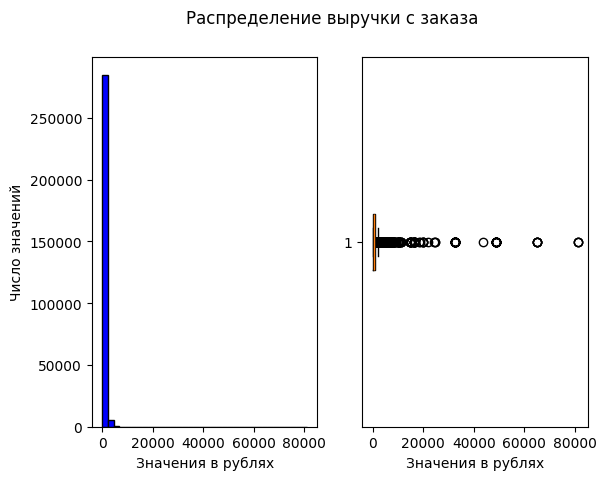

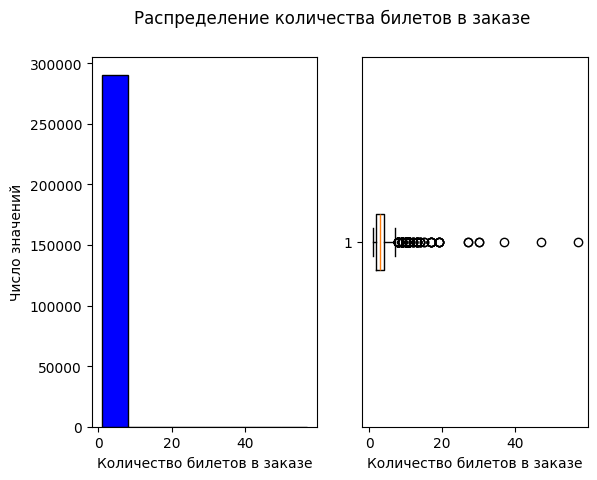

In [7]:
## 2.2.2 Проверка распределения численных данных 
## Проверка значений поля 'revenue_rub'
plt.subplot(1, 2, 1)
plt.suptitle('Распределение выручки с заказа')

plt.hist(
    df['revenue_rub'],
    color = 'blue',
    edgecolor = 'black',
    bins = int(180 / 5)
)
plt.xlabel('Значения в рублях')
plt.ylabel('Число значений')

plt.subplot(1, 2, 2)
plt.boxplot(
    data = df,
    x = 'revenue_rub',
    vert = False
)
plt.xlabel('Значения в рублях')

plt.show()

## Проверка значений поля 'tickets_count'
plt.subplot(1, 2, 1)
plt.suptitle('Распределение количества билетов в заказе')
plt.hist(
    df['tickets_count'],
    color = 'blue',
    edgecolor = 'black',
    bins = 8
)
plt.xlabel('Количество билетов в заказе')
plt.ylabel('Число значений')

plt.subplot(1, 2, 2)
plt.boxplot(
    data = df,
    x = 'tickets_count',
    vert = False
)
plt.xlabel('Количество билетов в заказе')

plt.show()

<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>В данных замечены аномальные выбросы - необходима фильтрация этих значений.</p>

np.float64(81174.54)

np.float64(555.5719866752087)

np.float64(351.14)

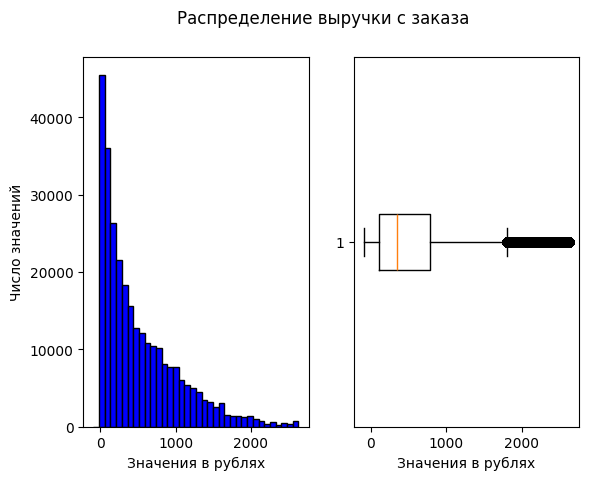

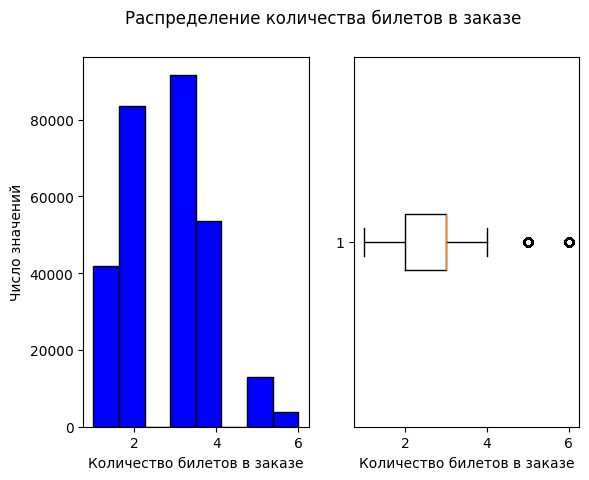

In [8]:
## Проверка статистических данных
display(df['revenue_rub'].max())
display(df['revenue_rub'].mean())
display(df['revenue_rub'].median())

## Фильтрация значений по 99 процентилю в полях 'revenue_rub' и 'tickets_count'
df = df[(df['revenue_rub'].quantile(0.99) >= df['revenue_rub']) & (df['tickets_count'].quantile(0.99) >= df['tickets_count'])]

## Новый вывод для оценки
plt.subplot(1, 2, 1)
plt.suptitle('Распределение выручки с заказа')

plt.hist(
    df['revenue_rub'],
    color = 'blue',
    edgecolor = 'black',
    bins = int(180 / 5)
)
plt.xlabel('Значения в рублях')
plt.ylabel('Число значений')

plt.subplot(1, 2, 2)
plt.boxplot(
    data = df,
    x = 'revenue_rub',
    vert = False
)
plt.xlabel('Значения в рублях')

plt.show()

## Проверка значений поля 'tickets_count'
plt.subplot(1, 2, 1)
plt.suptitle('Распределение количества билетов в заказе')
plt.hist(
    df['tickets_count'],
    color = 'blue',
    edgecolor = 'black',
    bins = 8
)
plt.xlabel('Количество билетов в заказе')
plt.ylabel('Число значений')

plt.subplot(1, 2, 2)
plt.boxplot(
    data = df,
    x = 'tickets_count',
    vert = False
)
plt.xlabel('Количество билетов в заказе')

plt.show()

<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Данные отфильтрованы по 99 процентилю в полях 'revenue_rub' и 'tickets_count'.</p>

In [9]:
## Тестовый вывод для проверки результата.
display(df.sample(5))
display(df.info())

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_name,event_type_main,region_name,city_name,rate,revenue_rub
189149,9cef262e4ff60dd,mobile,8496508,2024-10-27,2024-10-27 10:23:10,rub,479.10,5,31.0,329112,тебе билет!,3d9f7b36-b599-4f97-878b-193e82464e7a,театр,широковская область,вишнёво,19.9266,479.10
11094,06059d2ed94e762,mobile,1100638,2024-06-11,2024-06-11 15:55:17,rub,481.62,3,0.0,236500,прачечная,2c60a0c4-c637-41ef-a6c5-e8f09e311063,театр,каменевский регион,глиногорск,19.8928,481.62
116094,55c565ecb7cea49,mobile,5738608,2024-10-21,2024-10-21 18:42:00,rub,369.82,3,1.0,345623,мой билет,813579f0-3084-433d-8658-96335be4a117,стендап,североярская область,озёрск,19.7884,369.82
237939,cc99f89a866f810,desktop,5066359,2024-08-06,2024-08-06 15:07:41,rub,25.43,2,NaN,473460,билеты в руки,48797951-7adf-4b10-8c12-60eadb0cb303,другое,североярская область,озёрск,17.8998,25.43
7810,043f669c9f734b1,mobile,6781506,2024-08-29,2024-08-29 09:33:09,rub,72.40,2,1.0,554332,билеты в руки,bdb83faa-e008-4523-9294-0fa11a28a6cb,спорт,каменевский регион,глиногорск,19.0276,72.40


<class 'pandas.core.frame.DataFrame'>
Index: 287606 entries, 0 to 290610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287606 non-null  object        
 1   device_type_canonical  287606 non-null  category      
 2   order_id               287606 non-null  int32         
 3   order_dt               287606 non-null  datetime64[ns]
 4   order_ts               287606 non-null  datetime64[ns]
 5   currency_code          287606 non-null  category      
 6   revenue                287606 non-null  float64       
 7   tickets_count          287606 non-null  int8          
 8   days_since_prev        265881 non-null  float64       
 9   event_id               287606 non-null  int32         
 10  service_name           287606 non-null  category      
 11  event_name             287606 non-null  object        
 12  event_type_main        287606 non-null  category 

None

<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Общие выводы по предобработке данных - Поля в датафрейме преобразованы к наиболее подходящим типам данных, общий объем данных уменьшился до 287606 строк и занимает 22 мегабайта памяти. Данные представляющие собой категории преобразованы к единому формату, в данных исключены дубликаты. Данные отфильтрованы от выбросов по 99 процентилю, по полям 'revenue_rub' и 'tickets_count'.</p>

In [10]:
# 3 Создание профиля пользователя
## 3.1 Построение профиля пользователя
df = df.sort_values(by = 'order_dt', ascending = True)
df_profiles = df.groupby('user_id').agg({
    'order_dt': ['min', 'max'],
    'device_type_canonical': 'first',
    'region_name': 'first',
    'service_name': 'first',
    'event_type_main': 'first',
    'order_id': 'count',
    'revenue_rub': 'mean',
    'tickets_count': 'mean',
    'days_since_prev': 'mean'
})
## Функция возвращающая булевое значение по условию для полей 'is_two' и 'is_five'
def check_bool(x, a):  
    if x >= a: return True
    else: return False

## Расчет признаков 'is_two' и 'is_five'
df_profiles['is_two'] = df_profiles['order_id']['count'].apply(check_bool, a = 2)
df_profiles['is_five'] = df_profiles['order_id']['count'].apply(check_bool, a = 5)

## Приведение столбцов к необходимому формату
df_profiles = df_profiles.reset_index()

column_mapping = {
    'user_id': 'user_id',
    ('order_dt', 'min'): 'order_dt_first',
    ('order_dt', 'max'): 'order_dt_last',
    ('device_type_canonical', 'first'): 'device_type_canonical',
    ('region_name', 'first'): 'region_name',
    ('service_name', 'first'): 'service_name',
    ('event_type_main', 'first'): 'event_type_main',
    ('order_id', 'count'): 'order_id',
    ('revenue_rub', 'mean'): 'revenue_rub',
    ('tickets_count', 'mean'): 'tickets_count',
    ('days_since_prev', 'mean'): 'days_since_prev',
    'is_two': 'is_two',
    'is_five': 'is_five'
}

df_profiles.columns = df_profiles.columns.map(':'.join)
_list_names_columns = [event.split(':')[0] for event in df_profiles.columns]
_list_names_columns[1] = 'order_dt_first'
_list_names_columns[2] = 'order_dt_last'
df_profiles.columns = _list_names_columns

## Округение полей с длинной дробной частью
df_profiles['tickets_count'] = round(df_profiles['tickets_count'], 2)
df_profiles['revenue_rub'] = round(df_profiles['revenue_rub'], 2)
df_profiles['days_since_prev'] = round(df_profiles['days_since_prev'], 2)

display(df_profiles.sample(10))
display(df_profiles.info())

,user_id,order_dt_first,order_dt_last,device_type_canonical,region_name,service_name,event_type_main,order_id,revenue_rub,tickets_count,days_since_prev,is_two,is_five
9157,6acbeaa33e87c47,2024-06-18,2024-07-05,mobile,североярская область,билеты без проблем,другое,5,573.08,3.60,4.25,True,True
8254,602d71334a41ee9,2024-06-07,2024-10-07,mobile,североярская область,облачко,концерты,7,314.96,2.71,20.33,True,True
17359,ca867321b71a5bb,2024-09-12,2024-09-12,mobile,каменевский регион,билеты без проблем,другое,1,81.10,3.00,NaN,False,False
17147,c847e322ff0e274,2024-09-01,2024-09-01,mobile,североярская область,выступления.ру,концерты,1,742.14,3.00,NaN,False,False
19861,e84424768baf1b2,2024-07-07,2024-09-25,desktop,каменевский регион,билет по телефону,концерты,4,469.47,2.50,26.67,True,False
10829,7ef380441207bf4,2024-09-17,2024-09-23,mobile,североярская область,лучшие билеты,театр,3,963.53,4.00,3.00,True,False
13122,9a4d6b0453b70e8,2024-10-15,2024-10-21,mobile,медовская область,билеты без проблем,театр,2,38.68,2.00,6.00,True,False
18205,d4860c9ec715f6c,2024-08-27,2024-09-06,mobile,шанырский регион,мой билет,другое,6,864.95,3.83,2.00,True,True
17026,c6c99871c3c625a,2024-10-21,2024-10-29,desktop,каменевский регион,мой билет,концерты,3,562.20,2.33,4.00,True,False
21792,ff6bf53a0207b52,2024-09-11,2024-10-02,mobile,светополянский округ,билеты в руки,театр,3,596.15,3.00,10.50,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21847 entries, 0 to 21846
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                21847 non-null  object        
 1   order_dt_first         21847 non-null  datetime64[ns]
 2   order_dt_last          21847 non-null  datetime64[ns]
 3   device_type_canonical  21847 non-null  category      
 4   region_name            21847 non-null  category      
 5   service_name           21847 non-null  category      
 6   event_type_main        21847 non-null  category      
 7   order_id               21847 non-null  int64         
 8   revenue_rub            21847 non-null  float64       
 9   tickets_count          21847 non-null  float64       
 10  days_since_prev        13509 non-null  float64       
 11  is_two                 21847 non-null  bool          
 12  is_five                21847 non-null  bool          
dtypes

None

In [11]:
## 3.2 Рассчёт статистических показателей для оценки данных. 
print('Общее число пользователей в выборке: ', df_profiles['user_id'].count())
print('Средняя выручка с одного заказа: ', df_profiles['revenue_rub'].mean())
print('Доля пользователей, совершивших 2 и более заказа: ', df_profiles[(df_profiles['is_two'] == True)]['user_id'].count() / df_profiles['user_id'].count())
print('Доля пользователей, совершивших 5 и более заказов: ', df_profiles[(df_profiles['is_five'] == True)]['user_id'].count() / df_profiles['user_id'].count())

print('\nСтатистические показатели по общему числу заказов.')
display(df_profiles['order_id'].describe())
print('Статистические показатели по среднему числу билетов в заказе.')
display(df_profiles['tickets_count'].describe())
print('Статистические показатели по среднему количеству дней между покупками.')
display(df_profiles['days_since_prev'].describe())

## Фильтрация общего числа заказов по 99 процентилю в выборке.
df_profiles = df_profiles[(df_profiles['order_id'].quantile(0.99) >= df_profiles['order_id'])]

## Проверка показателей после фильтрации
print('\nСтатистические показатели по общему числу заказов.')
display(df_profiles['order_id'].describe())

Общее число пользователей в выборке:  21847
Средняя выручка с одного заказа:  544.1610614729711
Доля пользователей, совершивших 2 и более заказа:  0.6170183549228727
Доля пользователей, совершивших 5 и более заказов:  0.29006270883874213

Статистические показатели по общему числу заказов.


count    21847.000000
mean        13.164553
std        121.581813
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10168.000000
Name: order_id, dtype: float64

Статистические показатели по среднему числу билетов в заказе.


count    21847.000000
mean         2.739173
std          0.902699
min          1.000000
25%          2.000000
50%          2.750000
75%          3.070000
max          6.000000
Name: tickets_count, dtype: float64

Статистические показатели по среднему количеству дней между покупками.


count    13509.000000
mean        15.837189
std         22.289652
min          0.000000
25%          1.000000
50%          8.000000
75%         20.330000
max        148.000000
Name: days_since_prev, dtype: float64


Статистические показатели по общему числу заказов.


count    21628.000000
mean         6.479980
std         14.218483
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        151.000000
Name: order_id, dtype: float64

In [12]:
display(df_profiles.describe())
print('Общее число пользователей в выборке: ', df_profiles['user_id'].count())
print('Средняя выручка с одного заказа: ', df_profiles['revenue_rub'].mean())
print('Доля пользователей, совершивших 2 и более заказа: ', round(df_profiles['is_two'].mean(), 2), df_profiles['is_two'].sum())
print('Доля пользователей, совершивших 5 и более заказов: ', round(df_profiles['is_five'].mean(), 2), df_profiles['is_five'].sum())

,order_dt_first,order_dt_last,order_id,revenue_rub,tickets_count,days_since_prev
count,21628,21628,21628.000000,21628.000000,21628.000000,13290.000000
mean,2024-08-10 15:26:35.931200256,2024-09-17 21:37:51.056038400,6.479980,544.467864,2.739375,16.090484
min,2024-06-01 00:00:00,2024-06-01 00:00:00,1.000000,-10.770000,1.000000,0.000000
25%,2024-06-26 00:00:00,2024-08-24 00:00:00,1.000000,209.572500,2.000000,1.330000
50%,2024-08-09 00:00:00,2024-10-02 00:00:00,2.000000,462.985000,2.750000,8.355000
75%,2024-09-23 00:00:00,2024-10-22 00:00:00,5.000000,767.525000,3.090000,20.750000
max,2024-10-31 00:00:00,2024-10-31 00:00:00,151.000000,2628.420000,6.000000,148.000000
std,NaN,NaN,14.218483,433.659159,0.907120,22.384303


Общее число пользователей в выборке:  21628
Средняя выручка с одного заказа:  544.4678643425189
Доля пользователей, совершивших 2 и более заказа:  0.61 13261
Доля пользователей, совершивших 5 и более заказов:  0.28 6118


<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Сформирован профиль пользователя - в выборке представлены 21628 пользователей, средняя выручка с одного заказа - 544 рубля, 61 процента пользователей совершили 2 или более заказа, 28 процентов пользователей совершили 5 и более заказов. В данных при анализе статистических показателей, были выявлены выбросы в поле с общим числом заказов (10168). Была проведена фильтрация по 99 процентилю поля order_id. Все остальные данные следует оставить.</p>

In [13]:
# 4 Исследовательский анализ данных
## 4.1 Исследование признаков первого заказа и их связи с возвращением на платформу
### 4.1.1 Изучение распределения пользователей по признакам.
_t = df_profiles['user_id'].count()
df_arr = []
for item in ['event_type_main', 'device_type_canonical', 'region_name', 'service_name']:
    df_temp = df_profiles.groupby(item).agg({
        'user_id': 'count',  ## Расчёт общего количества пользователей
        'is_two': 'sum'  ## Расчёт общего количества пользователей совершивших 2 и более заказа для задачи 4.1.2
    })

    ## Процент от общего количества пользователей
    df_temp['per_user_id'] = round(df_temp['user_id'] / _t * 100, 2)
    ## Процент пользоветелей совершивших 2 и более заказа от количества пользователей в сегменте для задачи 4.1.2
    df_temp['per_is_two'] = round(df_temp['is_two'] / df_temp['user_id'] * 100, 2)
    
    df_temp = df_temp.sort_values(by = 'user_id', ascending = False)

    df_arr.append(df_temp.copy())

for _df in df_arr:
    display(_df.head(10))



C:\Users\noobo\AppData\Local\Temp\ipykernel_36120\209759867.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_temp = df_profiles.groupby(item).agg({
C:\Users\noobo\AppData\Local\Temp\ipykernel_36120\209759867.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_temp = df_profiles.groupby(item).agg({
C:\Users\noobo\AppData\Local\Temp\ipykernel_36120\209759867.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_t

,user_id,is_two,per_user_id,per_is_two
event_type_main,,,,
концерты,9563,5914,44.22,61.84
другое,5417,3227,25.05,59.57
театр,4229,2677,19.55,63.30
стендап,1113,679,5.15,61.01
спорт,797,446,3.69,55.96
выставки,415,266,1.92,64.10
ёлки,94,52,0.43,55.32


,user_id,is_two,per_user_id,per_is_two
device_type_canonical,,,,
mobile,17905,10880,82.79,60.77
desktop,3723,2381,17.21,63.95


,user_id,is_two,per_user_id,per_is_two
region_name,,,,
каменевский регион,7081,4417,32.74,62.38
североярская область,3759,2396,17.38,63.74
широковская область,1229,795,5.68,64.69
озернинский край,676,374,3.13,55.33
малиновоярский округ,520,289,2.40,55.58
шанырский регион,497,333,2.30,67.00
травяная область,488,300,2.26,61.48
светополянский округ,457,300,2.11,65.65
речиновская область,440,279,2.03,63.41


,user_id,is_two,per_user_id,per_is_two
service_name,,,,
билеты без проблем,5167,3117,23.89,60.33
мой билет,2970,1806,13.73,60.81
лови билет!,2798,1700,12.94,60.76
билеты в руки,2564,1610,11.86,62.79
облачко,2184,1341,10.10,61.40
весь в билетах,1285,808,5.94,62.88
лучшие билеты,1188,729,5.49,61.36
прачечная,578,360,2.67,62.28
край билетов,453,295,2.09,65.12


<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Данные по всем категориям распределены неравномерно. Выраженные точки входа по группам: По типу мероприятия - выделены 3 точки входа, концерты, теарты и другие типы со значениями от 4000 до 10000; По типу устройства - выделено мобильное устройство равное 17905; По типу региона - выделены 2 региона, каменевский регион и североярская область, со значениями 7081 и 3759; По типу билетного оператора - выделены 5 операторов, билеты без проблем - 5167, мой билет - 2970, лови билет! - 2798, билеты в руки - 2564, облачко - 2184.</p>
<p>Визуализация результатов представлена на следующем шаге.</p>

<Figure size 1600x1000 with 0 Axes>

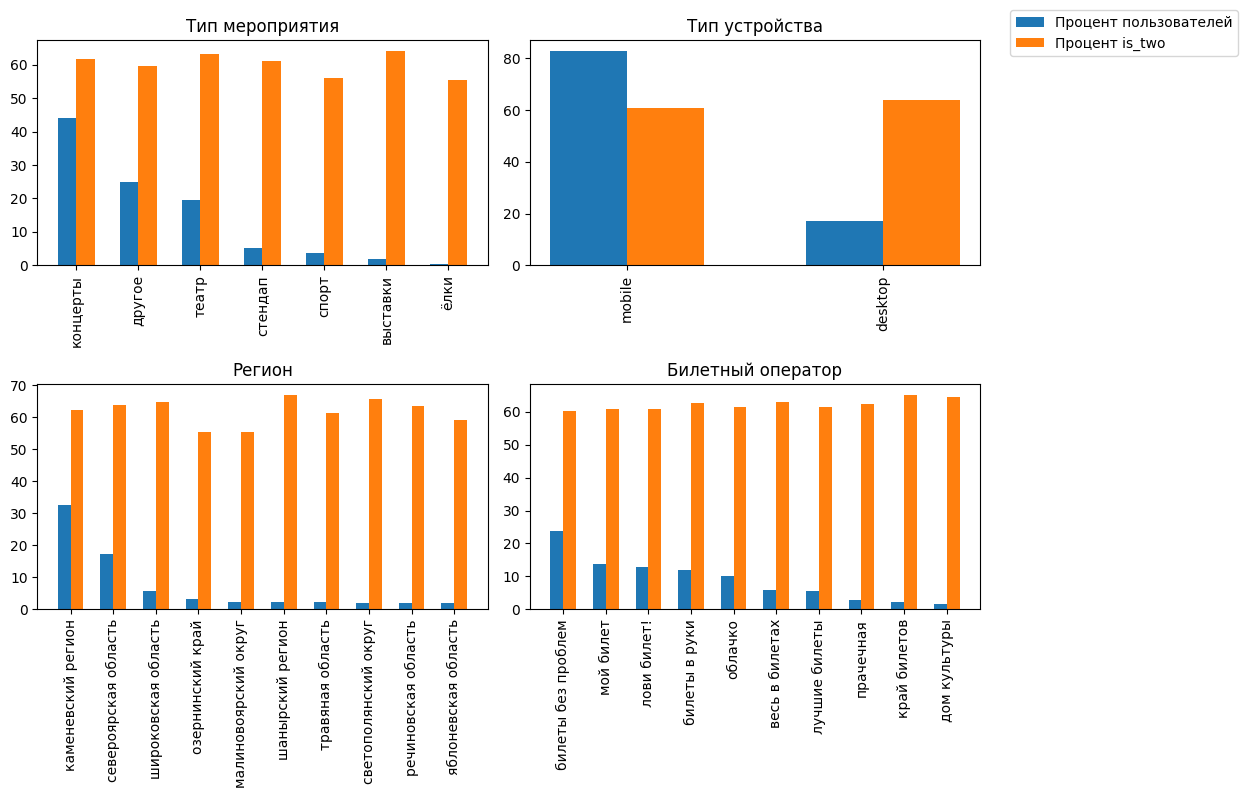

In [14]:
## 4.1 Исследование признаков первого заказа и их связи с возвращением на платформу
### 4.1.2 Анализ возврата пользователей

plt.figure(figsize=[16, 10])

width = 0.3
fig, axs = plt.subplots(2, 2, figsize = (10, 8))

for i, _df_temp in enumerate(df_arr):
    x_c = 0 if i <= 1 else 1
    y_c = i % 2

    df_temp_p = _df_temp.iloc[:10].copy()
    _index = df_temp_p.index.to_list()[:10]
    
    x = np.arange(len(_index))
    rects1 = axs[x_c, y_c].bar(x - width/2, df_temp_p['per_user_id'], width, label = 'Процент пользователей')
    rects2 = axs[x_c, y_c].bar(x + width/2, df_temp_p['per_is_two'], width, label = 'Процент is_two')
    
    axs[x_c, y_c].set_xticks(x)
    axs[x_c, y_c].set_xticklabels(_index)


for ax, title_name in zip(fig.axes, ['Тип мероприятия', 'Тип устройства', 'Регион', 'Билетный оператор']):
    matplotlib.pyplot.sca(ax)
    plt.xticks(rotation = 90)
#     plt.legend()
    ax.set_title(title_name)

fig.legend(['Процент пользователей', 'Процент is_two'], bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()


<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>На графике визуализированы по 2 столбца по каждой позиции в сегменте. Процент пользователей - процентное количество пользователей в каждом поле в сегменте относительно общего числа пользователей. Процент is_two - процентное количество пользователей совершишвых 2 и более заказа расчитанного по каждому полю сегмента отдельно.</p>
<p>В среднем, по всем сегментам наблюдаются примерно одинаковые показатели совершения повторного заказа пользователями - отмечаются процентные значения от 55 процентов до 67 процентов.</p>
<p>Наибольший процент возвратов по сегментам (точки входа): Тип мероприятия - театр и выставки (63, 64 процента), Тип устройства - desktop (63 процента), Регион - шанырский регион, светополянский округ, широковская область (67, 65 и 64 процента), Билетный оператор - край билетов, дом культуры (65, 64 процента).</p>
<p>Задача: 4.1.3</p>
<p>Гипотеза первая - Пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты? Пользователи совершившие свой первый на спортивные мероприятия, повторно возвращаются в 55 процентах случаев, пользователи оформившие свой первый заказ на концерты, повторно возвращаются в 61 проценте случаев. Гипотеза опровергнута.</p>
<p>Гипотеза вторая - В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах? Доля возвратов пользьзователей распределена примерно равномерно по всем регионам. Регионы, где больше всего пользователей почещают мероприятия, процент вернувшихся пользователей является высоким - от 62 до 64 процентов, что выше, чем в некоторых регионах, озеринский край - 55 процентов, малиновоярский округ - 55 процентов, яблоневская область - 59 процентов. Но есть регионы с более высокими показателями - шанырский регион - 67 процентов, светополянский округ - 65 процентов. Во многих регионах с малым совершением заказов - процент вернувшихся пользователей может быть выше, чем в регионах с большим количеством покупателей. Гипотеза опровергнута.</p>

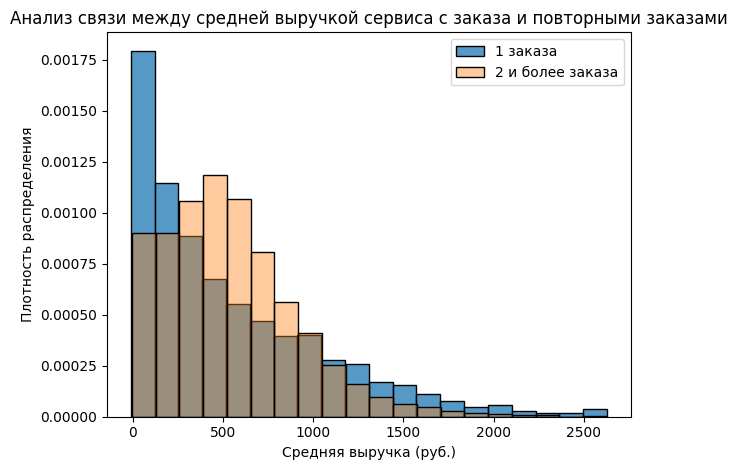

In [15]:
# 4.2 Исследование поведения пользователей через показатели выручки и состава заказа
# 4.2.1 Анализ связи между средней выручкой сервиса с заказа и повторными заказами

sns.histplot(
    data = df_profiles[(df_profiles['is_two'] == False)]['revenue_rub'],
    bins = 20,
    stat = 'density',
    label = '1 заказа'
)
sns.histplot(
    data = df_profiles[(df_profiles['is_two'] == True)]['revenue_rub'],
    bins = 20,
    alpha = 0.4,
    stat = 'density',
    label = '2 и более заказа'
)

plt.title('Анализ связи между средней выручкой сервиса с заказа и повторными заказами')
plt.legend()
plt.xlabel('Средняя выручка (руб.)')
plt.ylabel('Плотность распределения')
plt.tight_layout()
plt.show()

<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Средняя выручка пользователей совершивших один заказ концентрируется в основнюм среди маленьких значений от 0 до 250 рублей. С повышинием средней выручки, уменьшиется и число заказов.</p>
<p>Средняя выручка пользователей совершивших 2 и более заказа концентрируется в окгур значения в 500 рублей. С увеличением средней выручки, количество заказов уменьшается.</p>
<p>Пользователи, что совершают повторные заказы, чаще всего совершают заказы в диапазоне от 0 до 1000 рублей средней выручки. Пользователисовершившие всего 1 заказ, чаще совершают более дорогостоящие заказы.</p>

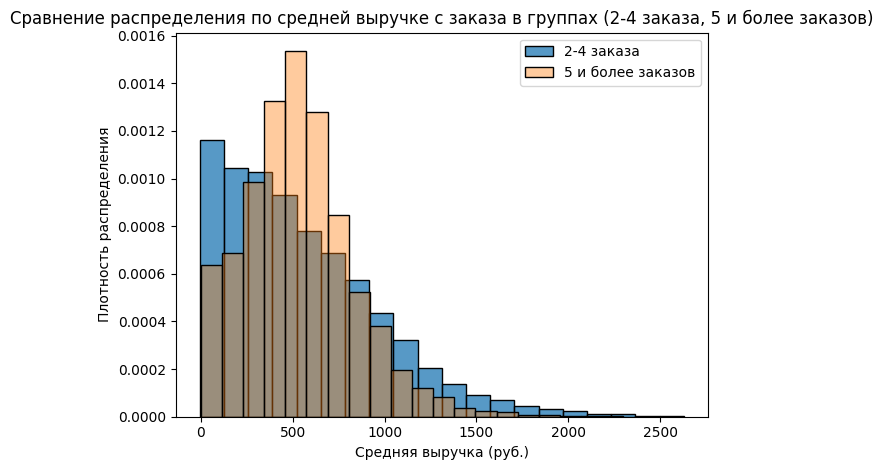

In [16]:
# 4.2.2 Сравнение распределения по средней выручке с заказа в группах (2-4 заказа, 5 и более заказов)
sns.histplot(
    data = df_profiles[(df_profiles['is_two'] == True) & (df_profiles['is_five'] == False)]['revenue_rub'],
    bins = 20,
    stat = 'density',
    label = '2-4 заказа'
)
sns.histplot(
    data = df_profiles[(df_profiles['is_five'] == True)]['revenue_rub'],
    bins = 20,
    alpha = 0.4,
    stat = 'density',
    label = '5 и более заказов'
)

plt.title('Сравнение распределения по средней выручке с заказа в группах (2-4 заказа, 5 и более заказов)')
plt.xlabel('Средняя выручка (руб.)')
plt.ylabel('Плотность распределения')
plt.legend()
plt.tight_layout()
plt.show()

## Моих знаний не хватает для выравнивания этих графиков, я не знаю как это сделать))

<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>График распределения средней выручки среди пользователей совершивших 2-4 заказа имеет правую ассиметрию с длинным правым хвостом - с увеличением выручки уменьшается и число заказов, пик распределения пользователей приходиться на диапазон средней выручки в диапазоне около 0-200 рублей. В обратном случае, пользователи совершившие 5 и более заказов, концентрируются в диапазоне от 250 до 750 рублей средней выручки. С увеличением средней выручки, количество заказов, также уменьшается. Пользователи совершающие много заказов, не часто делают дорогостоящие заказы.</p>

In [17]:
# 4.2.3 Анализ влияния среднего количества билетов в заказе на вероятность повторной покупки.
df_grouped = df_profiles.groupby('tickets_count').agg({'user_id': 'count', 'is_two': 'sum'}).reset_index()
df_grouped['segment'] =  pd.cut(df_grouped['tickets_count'], bins = [0, 2, 3, 4, 5, 100], labels = ['от 1 до 2 билетов', 'от 2 до 3 билетов', 'от 3 до 4 билетов', 'от 4 до 5 билетов', 'от 5 и более билетов'])
df_grouped = df_grouped.groupby('segment').agg({'user_id': 'sum', 'is_two': 'sum'})
df_grouped['is_two'] = round(df_grouped['is_two'] / df_grouped['user_id'], 2)
display(df_grouped)

C:\Users\noobo\AppData\Local\Temp\ipykernel_36120\3410863575.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df_grouped.groupby('segment').agg({'user_id': 'sum', 'is_two': 'sum'})


,user_id,is_two
segment,,
от 1 до 2 билетов,6163,0.40
от 2 до 3 билетов,9941,0.74
от 3 до 4 билетов,4575,0.65
от 4 до 5 билетов,770,0.47
от 5 и более билетов,179,0.30


<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Пользователи по сегментам сконцентрированы неравномерно - большая часть пользователей сконцентрирована в сегменте "от 2 до 3 билетов" - 9941 пользователь, затем идет семент "от 1 до 2 билетов" - 6163 пользователя, затем "от 3 до 4 билетов" и тд.</p>
<p>Самые высокие показатели повторного заказа, среди пользователей с количеством билетов в чеке "от 2 до 3 билетов" - 74 процента. аномально низкое знчение, среди пользователей с количеством билетов в чеке "от 5 и более билетов."</p>

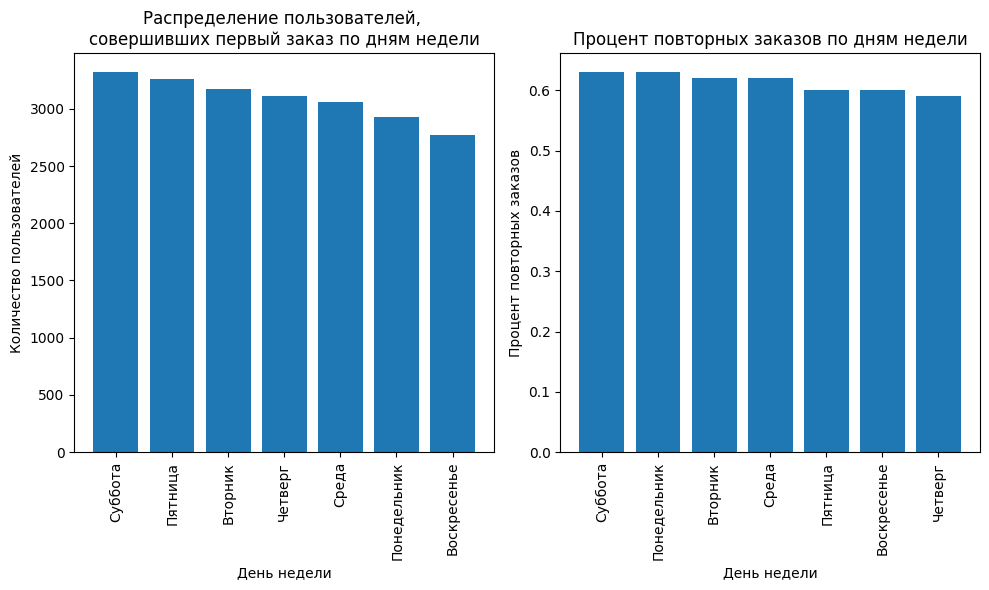

In [18]:
# 4.3 Исследование временных характеристик первого заказа и их влияния на повторные покупки.
# 4.3.1 Анализ влияния дня недели первой покупки на поведение пользователей.
df_days = df_profiles[['order_dt_first', 'is_two', 'user_id']].copy()
df_days['order_dt_first'] = df_days['order_dt_first'].dt.day_name()
df_days = df_days.groupby('order_dt_first').agg({'user_id': 'count', 'is_two': 'sum'})
df_days['is_two'] = round(df_days['is_two'] / df_days['user_id'], 2)
df_days = df_days.reset_index()
df_days = df_days.sort_values(by = 'user_id', ascending = False)
df_days['order_dt_first'] = ['Суббота', 'Пятница', 'Вторник', 'Четверг', 'Среда', 'Понедельник', 'Воскресенье']

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.bar(
    df_days['order_dt_first'],
    df_days['user_id']
)
plt.xticks(rotation = 90)
plt.xlabel('День недели')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей, \nсовершивших первый заказ по дням недели')

df_days = df_days.sort_values(by = 'is_two', ascending = False)
plt.subplot(1, 2, 2)
plt.bar(
    df_days['order_dt_first'],
    df_days['is_two']
)
plt.xticks(rotation = 90)
plt.xlabel('День недели')
plt.ylabel('Процент повторных заказов')
plt.title('Процент повторных заказов по дням недели')

plt.tight_layout()
plt.show()

<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Больше всего первых заказов, пользоветели совершают в промежутке с пятницы по субботу включительно. Средние показатели наблюдаются с вторника по четверг. Меньше всего заказов пользователи совершают в понедельник и воскресение.</p>
<p>Доля повторных заказов приходиться примерно в равной мере на все дни. Меньше всего в пятницу, четверг и воскресенье. Значения для всех дней недели находятся примерно в одинаковых значениях, в районе 60 процентов - День недели не сильно влияет на повторное совершение заказа пользователем.</p>

In [19]:
# 4.3.2 Анализ того, ка ксредний интервал между заказами влияет на удержание клиентов
# display(df_profiles)
df_days = df_profiles[(df_profiles['is_two'] == True)][['user_id', 'is_two', 'is_five', 'days_since_prev']].copy()
def user_segmentation(item):
    if item['is_five']:
        return 'совершившие 5 и более заказов'
    if item['is_two']:
        return 'совершившие 2-4 заказа'
df_days['segment'] = df_days.apply(user_segmentation, axis = 1)
df_days = df_days.groupby('segment').agg({'days_since_prev': 'mean', 'user_id': 'count'})
df_days['days_since_prev'] = round(df_days['days_since_prev'], 2)
display(df_days)


,days_since_prev,user_id
segment,,
совершившие 2-4 заказа,21.31,7143
совершившие 5 и более заказов,9.90,6118


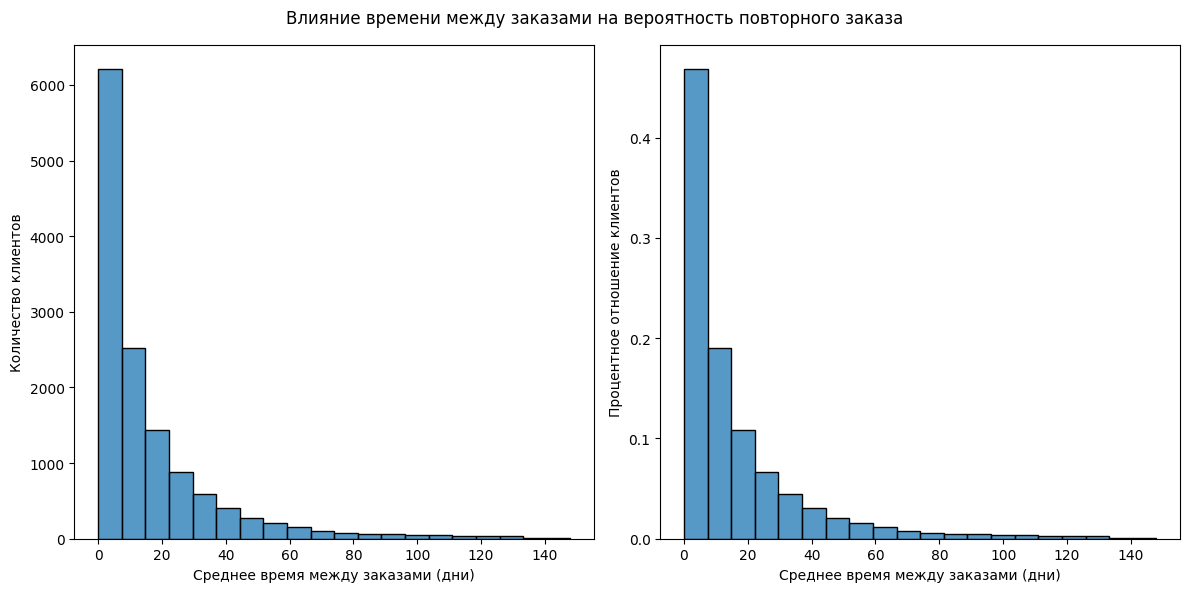

In [20]:
# 4.3.2 Анализ того, как средний интервал между заказами влияет на удержание клиентов
## Исследование, как средний интервал между заказами влияет на вероятность повторного заказа.

df_days = df_profiles[(df_profiles['is_two'] == True)][['user_id', 'days_since_prev']].copy()

plt.figure(figsize = (12, 6))

plt.subplot(1, 2, 1)
sns.histplot(
    data = df_days['days_since_prev'],
    bins = 20
)
plt.xlabel('Среднее время между заказами (дни)')
plt.ylabel('Количество клиентов')

plt.subplot(1, 2, 2)
sns.histplot(
    data = df_days['days_since_prev'],
    bins = 20,
    stat = 'probability'
)
plt.xlabel('Среднее время между заказами (дни)')
plt.ylabel('Процентное отношение клиентов')

plt.suptitle('Влияние времени между заказами на вероятность повторного заказа')
plt.tight_layout()
plt.show()

<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Для пользователей совершивших от 2 до 4 заказов средний интервал между заказами составляет примерно чуть больше 21 дня. Для пользователей совершивших от 5 и более заказов, средний интервал между заказами составляет немногим меньше 10 дней. Это говорит о том, чем больше заказов совершает пользователь, тем чаще он их совершает. Если между 2 заказами проходит довольно короткий промежуток времени - можно рассчитывать на возвращение клиента в будущем.</p>

<p>График распределения среднего времени между заказами по количеству повторных заказов имееет правую ассиметрию и длинный правый хвост. Пик значений приходится на промежуток от 0 до 10 дней - практически 50 процентов возвратов (> 6000 клиентов). На графиках видно, что чем больше времени проходит с момента предыдущего заказа, тем ниже вереятность повторного заказа. И также, верно обратное, чем меньше среднее время между заказами, тем выше вероятность повторного заказа. С увеличением среднего времени между заказами, уменьшается и количество клиентов совершивших 2 или более заказов.</p>

,user_id,order_dt_first,order_dt_last,device_type_canonical,region_name,service_name,event_type_main,order_id,revenue_rub,tickets_count,days_since_prev,is_two,is_five
7053,522597a333c9bb3,2024-06-11,2024-06-11,mobile,верхоречная область,мой билет,концерты,1,2628.42,3.0,NaN,False,False


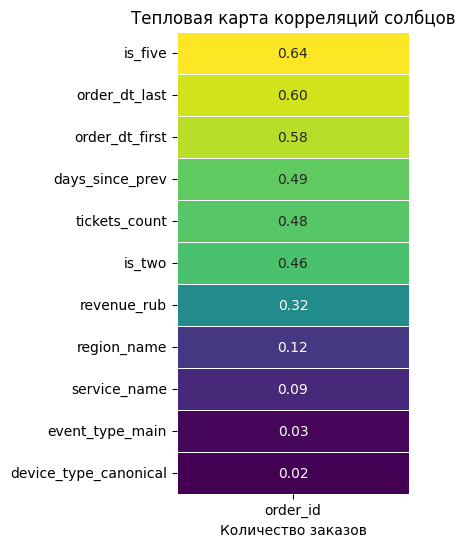

In [21]:
# 4.4 Корреляционный анализ количества покупок и признаков пользователя
display(df_profiles.sample(1))

df_phik = df_profiles[['order_id', 'order_dt_first', 'order_dt_last', 'device_type_canonical', 'region_name', 'service_name', 'event_type_main', 'revenue_rub', 'tickets_count', 'days_since_prev', 'is_two', 'is_five']].copy()
df_phik['order_id'] = pd.cut(df_phik['order_id'], bins = [0, 2, 5, 100], labels = ['1 заказ', 'от 2 до 4 заказов', 'от 5 и выше'])

df_phik = df_phik.phik_matrix(interval_cols = ['revenue_rub', 'tickets_count', 'days_since_prev'])
df_phik = df_phik.loc[df_phik.index != 'order_id'][['order_id']].sort_values(by = 'order_id', ascending = False)

plt.figure(figsize=(3, 6))

fig1 = sns.heatmap(
    data = df_phik, 
    annot = True, 
    fmt = '.2f', 
    linewidths = 0.5, 
    cmap = 'viridis',
    cbar = False
)
plt.title("Тепловая карта корреляций солбцов")
plt.xlabel('Количество заказов')

plt.show()

# display(df_phik)


<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>С количеством заказов все параметры имеют положительную корреляцию. Наиболее связь выражена с полями - "5 и более заказов", датой последнего заказа и датой первого заказа. Средняя связь наблюдается с полями - среднего количества дней с прошедшего заказа, количества билетов в заказе и "2 и более заказа". Немногим ниже средней связи, находится свясь с полем связаным со средней ценой заказа в рублях. Наименьшую связь имеют поля с регионом, названием сервиса, типом мероприятия и устройством с которого был оформлен заказа.</p>

<div class='alert alert-info' style='border: #1b009f solid 1px; padding: 20px'>
<b>Комментарий студента V1:</b> 
<p>Общие выводы и рекомендации</p>
<p>Анализ лояльности пользователей с Яндекс Афиши</p>
<p>Подготовка данных для работы - Для работ были взяты все необходимые данные данные с базы данных сервиса Яндекс Афиши. После выгрузки данных были предприняты следующие шаги - конвертация денежной выручки к одной валюте, российскому рублю, с помощью дополнительного набора данных, представленного в отдельном файле "final_tickets_tenge_df.csv". Выполнено преобразование столбцов в данных к необходимым форматам (типам данных) для упрощения дальнейшего анализа. Уменьшено количество занимаего места данными с 33 мегабайт до 22 мегабайт. Данные проверены на наличие пропусков и соответственно обработаны. Для последующего анализа, сформированы профили пльзователей со следующими полями (датой первого и последнего заказа, устройством, регионом, билетным партнером, жанром мероприятия, общим количеством заказов, средней выручкой с одного заказа в рублях, средним количеством билетов в заказе, средним временем между заказами, а также полями, совершал ли пользователь 2 заказа и 5 заказов.)</p>
<p>Основные результаты анализа:</p>
<ul>
    <li>Всего пользователей совершивших заказы - 21628 - средняя выручка с одного пользователя составляет 544 рубля. 61 процента пользователей севершило 2 или более заказа, что составляет примерно 13261 пользователей. 28 процентов пользователей совершило 5 и более заказов (примерно 6118 пользователей).</li>
    <li>Вероятность возвращения пользователя мало зависит от признаков первого заказа. Заблюдается небольшая закономерность в том, что чем меньше заказов было по определнному признаку, тем выше вероятность возврата покупателя на платформу. Точно можно отметить то, что заказы совершенные через компьютер имеют большую вероятность на возврат клиента на платформу относительно мобильных устройств.</li>
    <li>График средней выручки среди клиентов совершивших 2 и более заказа, имеет правую ассиметрию с выраженым правым хвостом. При увеличении средней выручки, количество заказов, также уменьшается - самые высокие показатели сконцентрированы в значении от 250 до 750 рублей средней выручки. По количеству билетов в заказе - наибольший процент повторных заказов отмечается при 2-3 билетах в заказе, 74 процента, также, это выбор наибольшего числа пользователей 9941. Всед за ним следует сегмент с 3-4 билетами в заказе - 65 процентов повторных заказов. Сегменты 1-2 и 4-5 заказов содержат процент возврата в 40%, 47% - наименьший процент возвратов, содержит сегмент 5 и более заказов - 30 процентов.</li>
    <li>Больше всего заказов впервые совершается в промежутке с пятницы по субботу. Процент повторных заказов примерно одинаковый по всем дням недели и составляет примерно 60 процентов, но больше всего выделяются Понедельник и Суббота - в эти дни процент повторных заказов выше 60 процентов и стремиться к 70 процентам. Анализ средних интервалов между покупками показывает, что чем больше покупок совершает пользователь, тем меньше интервал между покупками. Соответственно, от обратного справедливо ожитать, что если с прошлого заказа проходит короткий интервал, то от пользователя можно ожидать новый заказ. Среднее время между заказами у пользователей совершивших 5 и более покупок составляет 10 дней. У пользователей совершивших 2-4 заказа - 21 день.</li>
    <li>Прямую положительную связь с количеством заказов у пользователя имеют поля "дата первого заказа", "дата последнего заказа", "среднее время между заказами", "среднее количеством билетов в заказе" и "среднее значение выручки". Более слабую положительную связь иеют поля связанные с регионом заказа, сервисом, типом мероприятия и устройством с которого был оформлен заказ.</li>
</ul>
<p>В заключении можно добавить - следует обратить внимание, что большая вероятность возврата пользователей связана со средними значениями выручки в пределах от 250 до 750 рублей, количестве билетов в заказе от 2 до 4 билетов. Чаще всего заказы совершаются в период с пятницы по субботы - эти клиенты могут быть потенциальными и вернуться в будущем. Клиентам, которые часто делают заказы (среднее время 10 дней) - могут с большой долей вероятности вернуться в будущем, для них можно предлагать более выгодные условия. Следует обраить внимение на критерии распределения пользователей в которых сосредоточена весомая доля клиентов, например по типу мероприятия - большая часть клиентов сосредоточена в категориях (концерты, театры и другие типы). Больше всего пользователей пользуется мобильными устройствами - можно более сконцентрироваться на улучшении мобильного пользовательского интерфейса, для лучшего удержания клиентов и повышении количества возвратов. Регионам - Каменевский регион и североярская область показывают наибольшее количество пользователей. Также, стоит обратить внимение на билетных операторов "билеты без проблем", "мой билет", "лови билет!", "билеты в руки" и "облачко" - этими билетными операторами пользуется большее число пользователей.</p>